# STEM-EELS probe-position spectra

Load one or more `.npy` scans shaped `(sample, energy, probe_x, probe_y, px, py)`, integrate a configurable circular detector, and compare selected probe-position spectra.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

DATA_DIR = Path('/home/zuxian/Documents/PhD/STEM_EELS/STO_Sr-O')
FIG_DIR = DATA_DIR / 'figures'

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.linewidth': 1.0,
    'font.size': 13,
})


# Theta

In [15]:
import numpy as np


def tacaw_theta_grid(V, Lx, Ly, theta_max=100):
    """
    Generate TACAW scattering angle grid.

    Parameters
    ----------
    V : float
        Electron accelerating voltage in volts.

    Lx, Ly : float
        Simulation cell dimensions in Angstrom.

    theta_max : float
        Maximum scattering angle in mrad.
        The output range is approximately [-theta_max, theta_max].

    Returns
    -------
    theta_x : ndarray
        x-axis scattering angles (mrad).

    theta_y : ndarray
        y-axis scattering angles (mrad).

    Theta_x, Theta_y : ndarray
        2D angular coordinate grids (mrad).

    Theta : ndarray
        2D total scattering angle grid (mrad).
    """

    # Physical constants
    h = 6.62607015e-34        # Planck constant (J s)
    me = 9.1093837015e-31     # electron mass (kg)
    e = 1.602176634e-19       # elementary charge (C)
    c = 299792458             # speed of light (m/s)


    # Relativistic electron wavelength
    lambda_m = h / np.sqrt(
        2 * me * e * V *
        (1 + e * V / (2 * me * c**2))
    )

    lambda_A = lambda_m * 1e10   # meter -> Angstrom

    # Electron wavevector
    k0 = 1 / lambda_A


    # Angular pixel spacing (mrad)
    dtheta_x = 1000 / (Lx * k0)
    dtheta_y = 1000 / (Ly * k0)


    # FFT index range
    nx = int(np.floor(theta_max / dtheta_x))
    ny = int(np.floor(theta_max / dtheta_y))


    # Angular coordinates
    theta_x = np.arange(-nx, nx + 1) * dtheta_x
    theta_y = np.arange(-ny, ny + 1) * dtheta_y


    # 2D angular grid
    Theta_x, Theta_y = np.meshgrid(
        theta_x,
        theta_y,
        indexing="xy"
    )

    Theta = np.sqrt(
        Theta_x**2 + Theta_y**2
    )


    return theta_x, theta_y, Theta_x, Theta_y, Theta
    
    
    ''' 
    Example
    V = 60000  # 60 keV

    Lx = 39.09047055906947
    Ly = 39.09515918269145

    theta_x, theta_y, Theta_x, Theta_y, Theta = tacaw_theta_grid(
        V,
        Lx,
        Ly,
        theta_max=100
    )

    print(theta_x.shape)
    print(theta_y.shape)
    print(theta_x[0], theta_x[-1])
    '''

In [26]:
theta_x, theta_y, Theta_x, Theta_y, Theta =tacaw_theta_grid(60000, 39.090, 39.095, theta_max=120)

np.diff(theta_x)[0], np.diff(theta_y)[0]

(1.24483512483188, 1.2446759183956715)

In [27]:
theta_x, theta_y, Theta_x, Theta_y, Theta =tacaw_theta_grid(60000, 40.233, 40.145, theta_max=120)

np.diff(theta_x)[0], np.diff(theta_y)[0]    

(1.2094699632062884, 1.2121211864411237)

## Energy axis

In [8]:
def energy_loss_axis_mev(chunk, timestep_fs=2.5, stride=3):
    """Return an FFT-shifted energy-loss axis in meV."""
    frequency_thz = np.fft.fftshift(
        np.fft.fftfreq(chunk, timestep_fs * stride / 1000.0)
    )
    return frequency_thz * 4.13566769692386


## Detector and probe extraction

In [9]:
def circular_detector_mask(shape, center=None, radius=20):
    """Return a circular mask; ``center`` is given as ``(px, py)``."""
    if len(shape) != 2:
        raise ValueError(f'Detector plane must be 2D, got shape={shape}')
    if radius <= 0:
        raise ValueError(f'Detector radius must be positive, got {radius}')

    n_px, n_py = shape
    if center is None:
        center = (n_px // 2, n_py // 2)
    center_px, center_py = center
    if not (0 <= center_px < n_px and 0 <= center_py < n_py):
        raise ValueError(f'Detector center {center} is outside detector shape {shape}')

    px, py = np.ogrid[:n_px, :n_py]
    return (px - center_px) ** 2 + (py - center_py) ** 2 <= radius ** 2


def extract_probe_data_3d(scan, probe_x, probe_y=0, sample=0):
    """Return one probe position as an ``(energy, px, py)`` array."""
    return np.asarray(scan[sample, :, probe_x, probe_y, :, :])


def normalize_probe_data_3d(probe_data_3d):
    """Normalize a probe block so its sum over ``(energy, px, py)`` is 1."""
    total = probe_data_3d.sum()
    if not np.isfinite(total) or total == 0:
        raise ValueError(f'Cannot normalize 3D probe data with sum={total}')
    return probe_data_3d / total


def detector_spectrum_from_probe_data(
    probe_data_3d,
    radius=20,
    detector_center=None,
):
    """Integrate an ``(energy, px, py)`` probe block over detector pixels."""
    mask = circular_detector_mask(
        probe_data_3d.shape[-2:],
        center=detector_center,
        radius=radius,
    )
    return probe_data_3d[:, mask].sum(axis=1)


def extract_probe_spectrum(
    scan,
    probe_x,
    probe_y=0,
    radius=20,
    detector_center=None,
    sample=0,
    normalize_3d=False,
):
    """Extract and detector-integrate one probe-position spectrum."""
    probe_data_3d = extract_probe_data_3d(
        scan,
        probe_x=probe_x,
        probe_y=probe_y,
        sample=sample,
    )
    if normalize_3d:
        probe_data_3d = normalize_probe_data_3d(probe_data_3d)
    return detector_spectrum_from_probe_data(
        probe_data_3d,
        radius=radius,
        detector_center=detector_center,
    )


## File loading and plotting

In [10]:
def plot_eels_probe_positions(
    input_files,
    energy_mev=None,
    *,
    detector_radius=20,
    detector_center=None,
    probe_x_indices=(0,),
    probe_y_index=0,
    sample=0,
    normalize_3d=True,
    file_labels=None,
    timestep_fs=2.5,
    stride=3,
    use_log=True,
    x_limits=(-150, 150),
    y_limits=None,
    save_path=None,
    save_data=False,
    data_path=None,
    intensity_label='Detector intensity',
):
    """Load one or more scan files, extract selected probes, and plot EELS.

    Each input array must have shape
    ``(sample, energy, probe_x, probe_y, px, py)``. Files are memory-mapped,
    so only the requested probe blocks are read into memory. ``detector_center``
    uses ``(px, py)`` coordinates. If ``save_data=True``, one NumPy array
    with shape ``(n_curves, n_energy, 2)`` is saved to ``data_path``; its
    last dimension contains ``[energy_meV, intensity]``. No labels file is
    written. Returns ``(fig, ax, curves)``.
    """
    if isinstance(input_files, (str, Path)):
        input_files = [input_files]
    paths = [Path(path) for path in input_files]
    if not paths:
        raise ValueError('input_files must contain at least one .npy file')

    probe_x_indices = list(probe_x_indices)
    if not probe_x_indices:
        raise ValueError('probe_x_indices must contain at least one index')

    if file_labels is None:
        file_labels = [path.stem for path in paths]
    else:
        file_labels = list(file_labels)
    if len(file_labels) != len(paths):
        raise ValueError('file_labels and input_files must have the same length')
    if len(set(file_labels)) != len(file_labels):
        raise ValueError('file_labels must be unique')

    curves = {}
    n_energy_expected = None
    for path, file_label in zip(paths, file_labels):
        if not path.is_file():
            raise FileNotFoundError(path)
        scan = np.load(path, mmap_mode='r')
        if scan.ndim != 6:
            raise ValueError(f'{path.name}: expected a 6D scan, got shape {scan.shape}')

        n_samples, n_energy, n_probe_x, n_probe_y, n_px, n_py = scan.shape
        if n_energy_expected is None:
            n_energy_expected = n_energy
        elif n_energy != n_energy_expected:
            raise ValueError(
                f'{path.name}: energy length {n_energy} does not match {n_energy_expected}'
            )
        if not 0 <= sample < n_samples:
            raise IndexError(f'{path.name}: sample={sample} outside [0, {n_samples})')
        if not 0 <= probe_y_index < n_probe_y:
            raise IndexError(
                f'{path.name}: probe_y_index={probe_y_index} outside [0, {n_probe_y})'
            )

        center = (
            detector_center
            if detector_center is not None
            else (n_px // 2, n_py // 2)
        )
        circular_detector_mask(
            (n_px, n_py),
            center=center,
            radius=detector_radius,
        )
        for probe_x_index in probe_x_indices:
            if not 0 <= probe_x_index < n_probe_x:
                raise IndexError(
                    f'{path.name}: probe_x_index={probe_x_index} outside [0, {n_probe_x})'
                )
            spectrum = extract_probe_spectrum(
                scan,
                probe_x=probe_x_index,
                probe_y=probe_y_index,
                radius=detector_radius,
                detector_center=center,
                sample=sample,
                normalize_3d=normalize_3d,
            )
            label = file_label
            if len(probe_x_indices) > 1:
                label = f'{file_label} | x={probe_x_index}, y={probe_y_index}'
            curves[label] = spectrum

    if energy_mev is None:
        energy_axis = energy_loss_axis_mev(
            n_energy_expected,
            timestep_fs=timestep_fs,
            stride=stride,
        )
    else:
        energy_axis = np.asarray(energy_mev)
        if energy_axis.ndim != 1 or energy_axis.size != n_energy_expected:
            raise ValueError(
                f'energy_mev must have shape ({n_energy_expected},), got {energy_axis.shape}'
            )

    if save_data:
        if data_path is None:
            raise ValueError('data_path is required when save_data=True')
        all_spectra = []
        for label, detector_intensity in curves.items():
            eels = np.asarray(detector_intensity)
            if eels.shape != energy_axis.shape:
                raise ValueError(
                    f'{label} spectrum shape {eels.shape} does not match '
                    f'energy axis shape {energy_axis.shape}'
                )
            all_spectra.append(np.column_stack((energy_axis, eels)))

        all_spectra = np.stack(all_spectra)
        data_path = Path(data_path)
        if data_path.suffix != '.npy':
            data_path = data_path.with_suffix('.npy')
        data_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(data_path, all_spectra)
        print(f'Saved spectra with shape {all_spectra.shape} to {data_path}')

    eps = np.finfo(float).tiny
    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(curves)))
    fig, ax_main = plt.subplots(figsize=(15, 6))
    for (label, spectrum), color in zip(curves.items(), colors):
        y = np.clip(spectrum, eps, None) if use_log else spectrum
        y_plot = np.log10(y) if use_log else y
        ax_main.plot(
            energy_axis,
            y_plot,
            color=color,
            linewidth=1.8,
            label=label,
        )

    y_label = (
        rf'$\log_{{10}}(\mathrm{{{intensity_label}}})$'
        if use_log
        else intensity_label
    )
    if x_limits is not None:
        ax_main.set_xlim(x_limits)
    if y_limits is not None:
        ax_main.set_ylim(y_limits)
    ax_main.set_xlabel('Energy loss (meV)', fontsize=15)
    ax_main.set_ylabel(y_label, fontsize=15)
    ax_main.tick_params(axis='both', which='major', labelsize=14)
    center_text = detector_center if detector_center is not None else 'array center'
    ax_main.legend(
        title=(
            f'radius={detector_radius} px, center={center_text}; '
            f'probe y={probe_y_index}'
        ),
        ncol=2,
        frameon=True,
        loc='upper left',
        fontsize=12,
        title_fontsize=12,
    )

    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    return fig, ax_main, curves


## Diffraction-pattern detector preview

In [11]:
def plot_diffraction_pattern_with_detector(
    input_file,
    energy_value_mev=0.0,
    *,
    detector_radius=20,
    detector_center=None,
    probe_x_indices=(0,),
    probe_y_index=0,
    sample=0,
    energy_mev=None,
    timestep_fs=2.5,
    stride=3,
    use_log=True,
    cmap='viridis',
    save_path=None,
):
    """Plot diffraction patterns and overlay the circular detector in red.

    The scan must have shape
    ``(sample, energy, probe_x, probe_y, px, py)``. The energy bin nearest
    ``energy_value_mev`` is selected. Both ``detector_center`` and the array
    axes use the ``(px, py)`` convention. Returns ``(fig, axes)``.
    """
    path = Path(input_file)
    if not path.is_file():
        raise FileNotFoundError(path)

    scan = np.load(path, mmap_mode='r')
    if scan.ndim != 6:
        raise ValueError(f'{path.name}: expected a 6D scan, got shape {scan.shape}')

    n_samples, n_energy, n_probe_x, n_probe_y, n_px, n_py = scan.shape
    if not 0 <= sample < n_samples:
        raise IndexError(f'{path.name}: sample={sample} outside [0, {n_samples})')
    if not 0 <= probe_y_index < n_probe_y:
        raise IndexError(
            f'{path.name}: probe_y_index={probe_y_index} outside [0, {n_probe_y})'
        )

    probe_x_indices = list(probe_x_indices)
    if not probe_x_indices:
        raise ValueError('probe_x_indices must contain at least one index')
    for probe_x_index in probe_x_indices:
        if not 0 <= probe_x_index < n_probe_x:
            raise IndexError(
                f'{path.name}: probe_x_index={probe_x_index} outside [0, {n_probe_x})'
            )

    center = (
        detector_center
        if detector_center is not None
        else (n_px // 2, n_py // 2)
    )
    circular_detector_mask(
        (n_px, n_py),
        center=center,
        radius=detector_radius,
    )

    if energy_mev is None:
        energy_axis = energy_loss_axis_mev(
            n_energy,
            timestep_fs=timestep_fs,
            stride=stride,
        )
    else:
        energy_axis = np.asarray(energy_mev)
        if energy_axis.ndim != 1 or energy_axis.size != n_energy:
            raise ValueError(
                f'energy_mev must have shape ({n_energy},), got {energy_axis.shape}'
            )

    energy_index = int(np.argmin(np.abs(energy_axis - energy_value_mev)))
    selected_energy_mev = float(energy_axis[energy_index])
    fig, axes = plt.subplots(
        1,
        len(probe_x_indices),
        figsize=(6 * len(probe_x_indices), 5),
        squeeze=False,
    )
    axes = axes.ravel()

    center_px, center_py = center
    for ax, probe_x_index in zip(axes, probe_x_indices):
        pattern = np.asarray(
            scan[sample, energy_index, probe_x_index, probe_y_index, :, :]
        )
        if use_log:
            positive = pattern[np.isfinite(pattern) & (pattern > 0)]
            if positive.size == 0:
                raise ValueError('Cannot use log scale: pattern has no positive values')
            image_data = np.log10(np.clip(pattern, positive.min(), None))
            colorbar_label = r'$\log_{10}(\mathrm{intensity})$'
        else:
            image_data = pattern
            colorbar_label = 'Intensity'

        image = ax.imshow(image_data, origin='lower', cmap=cmap)
        detector_circle = plt.Circle(
            (center_py, center_px),
            detector_radius,
            fill=False,
            edgecolor='red',
            linewidth=2.0,
            label=f'Detector radius = {detector_radius} px',
        )
        ax.add_patch(detector_circle)
        ax.set_title(f'probe x={probe_x_index}, y={probe_y_index}')
        ax.set_xlabel('py (pixel)')
        ax.set_ylabel('px (pixel)')
        ax.legend(loc='upper right', frameon=True)
        fig.colorbar(image, ax=ax, label=colorbar_label)

    fig.suptitle(
        f'{path.name}: requested {energy_value_mev:g} meV, '
        f'nearest bin {selected_energy_mev:.6g} meV (index {energy_index})'
    )
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    return fig, axes


## EELS example

Saved spectra with shape (40, 600, 2) to /home/zuxian/Documents/PhD/STEM_EELS/STO_Sr-O/STO_Sr-O_bussi_60chunks_x0mrad_y-62mrad_Int25mrad.npy


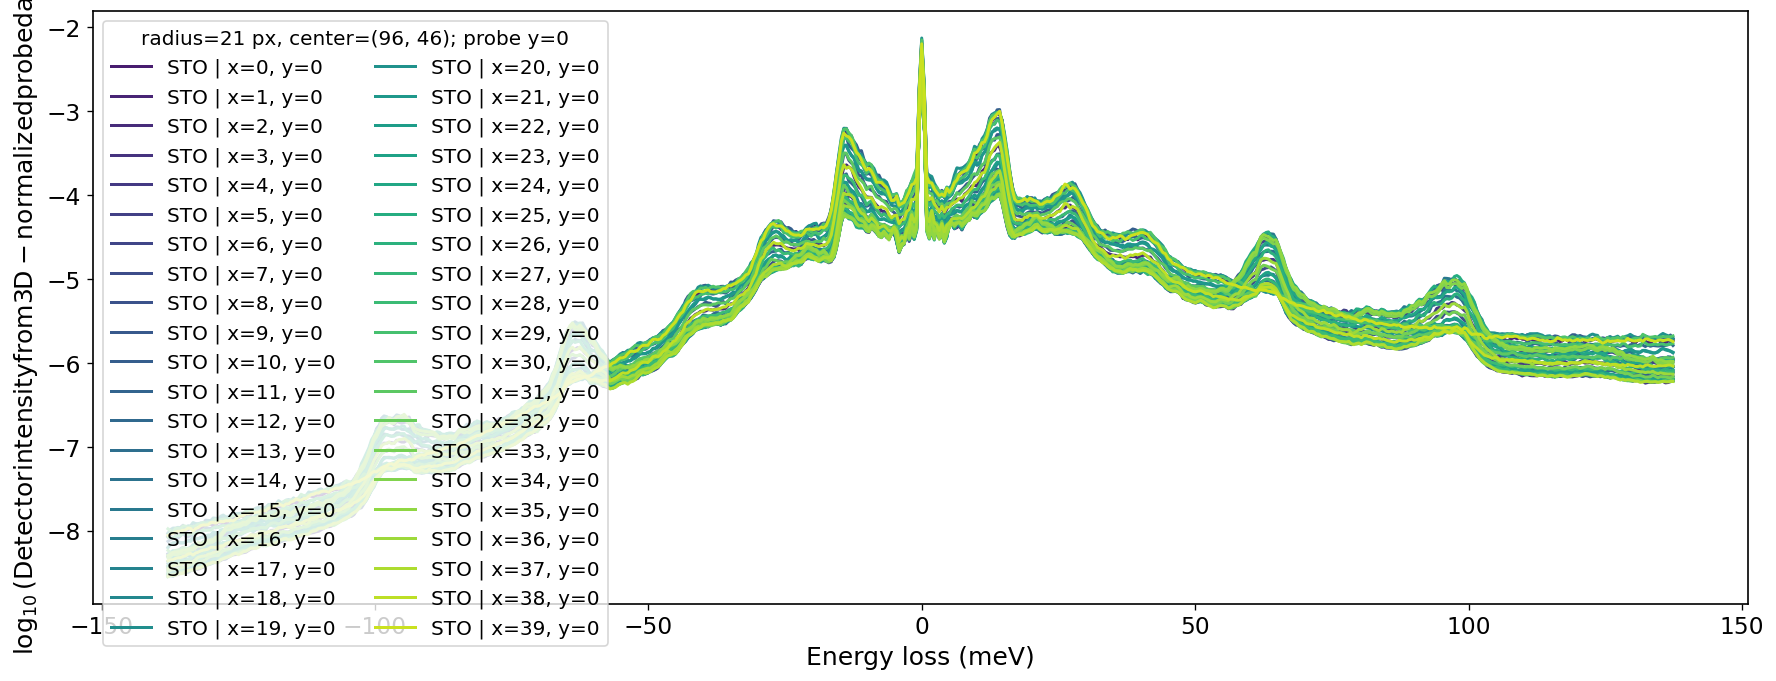

In [36]:
# older lattice parameter 4H_SiC_110_rep3x6x82_T300K_beads1_steps20000_20260825_052109.

input_files = [
    DATA_DIR / 'STO_Sr-O_bussi.npy',

]
file_labels = [
    'STO',
]

# Read only the array metadata needed to define the shifted detector center.
first_scan = np.load(input_files[0], mmap_mode='r')
N_PX, N_PY = first_scan.shape[-2:]
del first_scan

detector_radius = 21
detector_center = (N_PX // 2 , N_PY // 2 - 50)
probe_x_indices = list(range(40))
probe_y_index = 0
data_path = DATA_DIR / 'STO_Sr-O_bussi_60chunks_x0mrad_y-62mrad_Int25mrad.npy'

fig, ax, curves = plot_eels_probe_positions(
    input_files,
    energy_mev=None,
    detector_radius=detector_radius,
    detector_center=detector_center,
    probe_x_indices=probe_x_indices,
    probe_y_index=probe_y_index,
    sample=0,
    normalize_3d=False,
    file_labels=file_labels,
    timestep_fs=5,
    stride=3,
    use_log=True,
    x_limits=None,
    y_limits=None,
    save_path=FIG_DIR / 'STEM_EELS_QT_Si_selected_files_and_probes.svg',
    save_data=True,
    data_path=data_path,
    intensity_label='Detector intensity from 3D-normalized probe data',
)



## Diffraction-pattern example at 0 meV

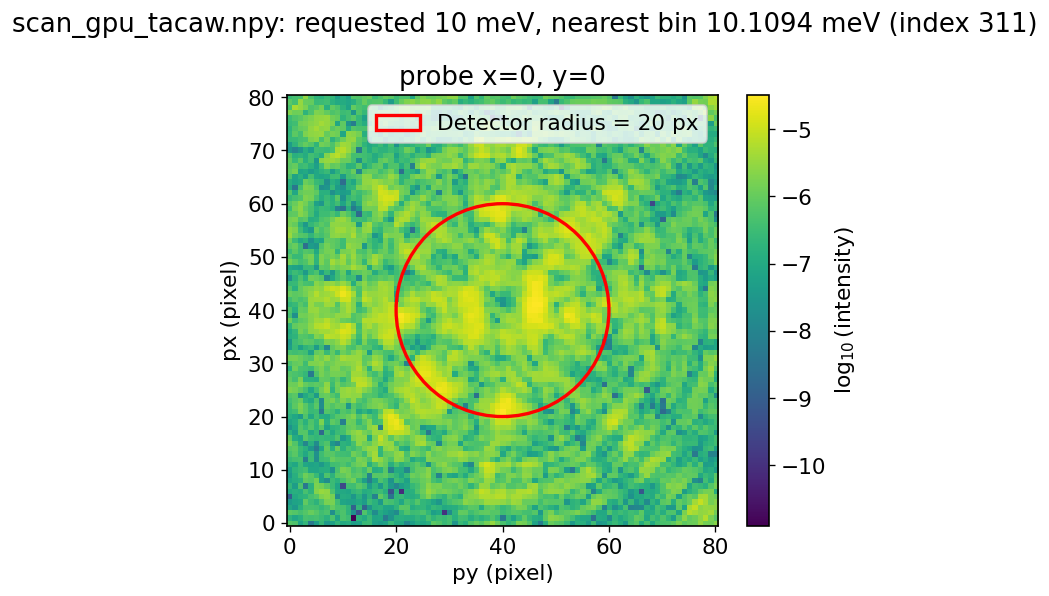

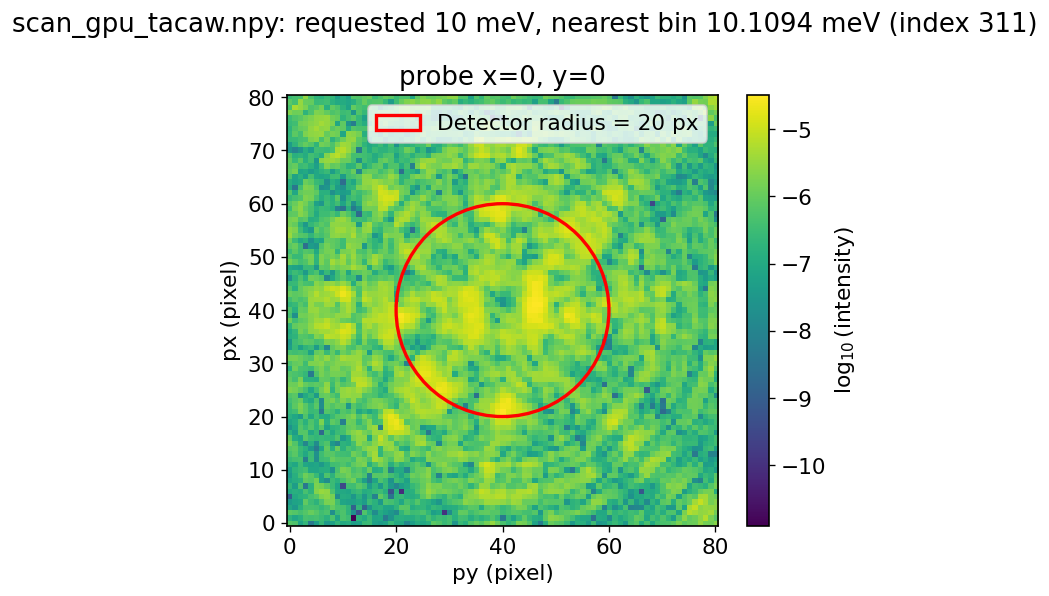

In [28]:
diffraction_file = DATA_DIR / 'scan_gpu_tacaw.npy'

# Read only the shape metadata needed for the shifted detector center.
diffraction_scan = np.load(diffraction_file, mmap_mode='r')
N_PX, N_PY = diffraction_scan.shape[-2:]
del diffraction_scan

detector_radius = 20
detector_center = (N_PX // 2, N_PY // 2)
probe_x_indices = [0]
probe_y_index = 0

diffraction_fig, diffraction_axes = plot_diffraction_pattern_with_detector(
    diffraction_file,
    energy_value_mev=10.0,
    detector_radius=detector_radius,
    detector_center=detector_center,
    probe_x_indices=probe_x_indices,
    probe_y_index=probe_y_index,
    sample=0,
    timestep_fs=2.5,
    stride=3,
    use_log=True,
    cmap='viridis',
    save_path=None,
)

diffraction_fig
